In [1]:
# Load packages
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import scipy.stats as scs

from FDApy import DenseFunctionalData, MultivariateFunctionalData
from FDApy.representation import DenseArgvals, DenseValues
from FDApy.preprocessing import MFPCA, UFPCA
from FDApy.visualization import plot, plot_multivariate

from nba import NbaScraper, ShotCharts


plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r'\usepackage{amsfonts}'
})

COLORS = {
    'Guard': '#648FFF',
    'Forward-Guard': '#785EF0',
    'Forward': '#DC267F',
    'Forward-Center': '#FE6100',
    'Center': '#FFB000'
}

POSITION_CAT = {
    'Guard': 1,
    'Forward-Guard': 2,
    'Forward': 3,
    'Forward-Center': 4,
    'Center': 5
}


In [2]:
# Load data
with open('./data/players_shots_density.pickle', 'rb') as f:
    players_shots_density = pickle.load(f)
with open('./data/player_position.pickle', 'rb') as f:
    players_position = pickle.load(f)

# Load UFPCA results
with open('./data/UFPCA.pickle', 'rb') as f:
    ufpca = pickle.load(f)
with open('./data/scores_ufpca.pickle', 'rb') as f:
    scores = pickle.load(f)
with open('./data/UFPCA_reconstruction.pickle', 'rb') as f:
    fdata_reconstruction = pickle.load(f)

# Load clustering results
with open('./data/clustering_univ.pickle', 'rb') as f:
    clustering = pickle.load(f)
with open('./data/distance_scores_univ.pickle', 'rb') as f:
    distance_scores = pickle.load(f)

In [3]:
# Reshape scores
scores = pd.DataFrame(scores)
scores.insert(loc=0, column='PLAYER_ID', value=players_shots_density.PLAYER_ID.values)
scores.insert(loc=0, column='PLAYER_NAME', value=players_shots_density.PLAYER_NAME.values)
scores = scores.join(players_position.set_index('PLAYER_ID'), how='left', on='PLAYER_ID', rsuffix='_')
scores['cluster'] = clustering['pred']

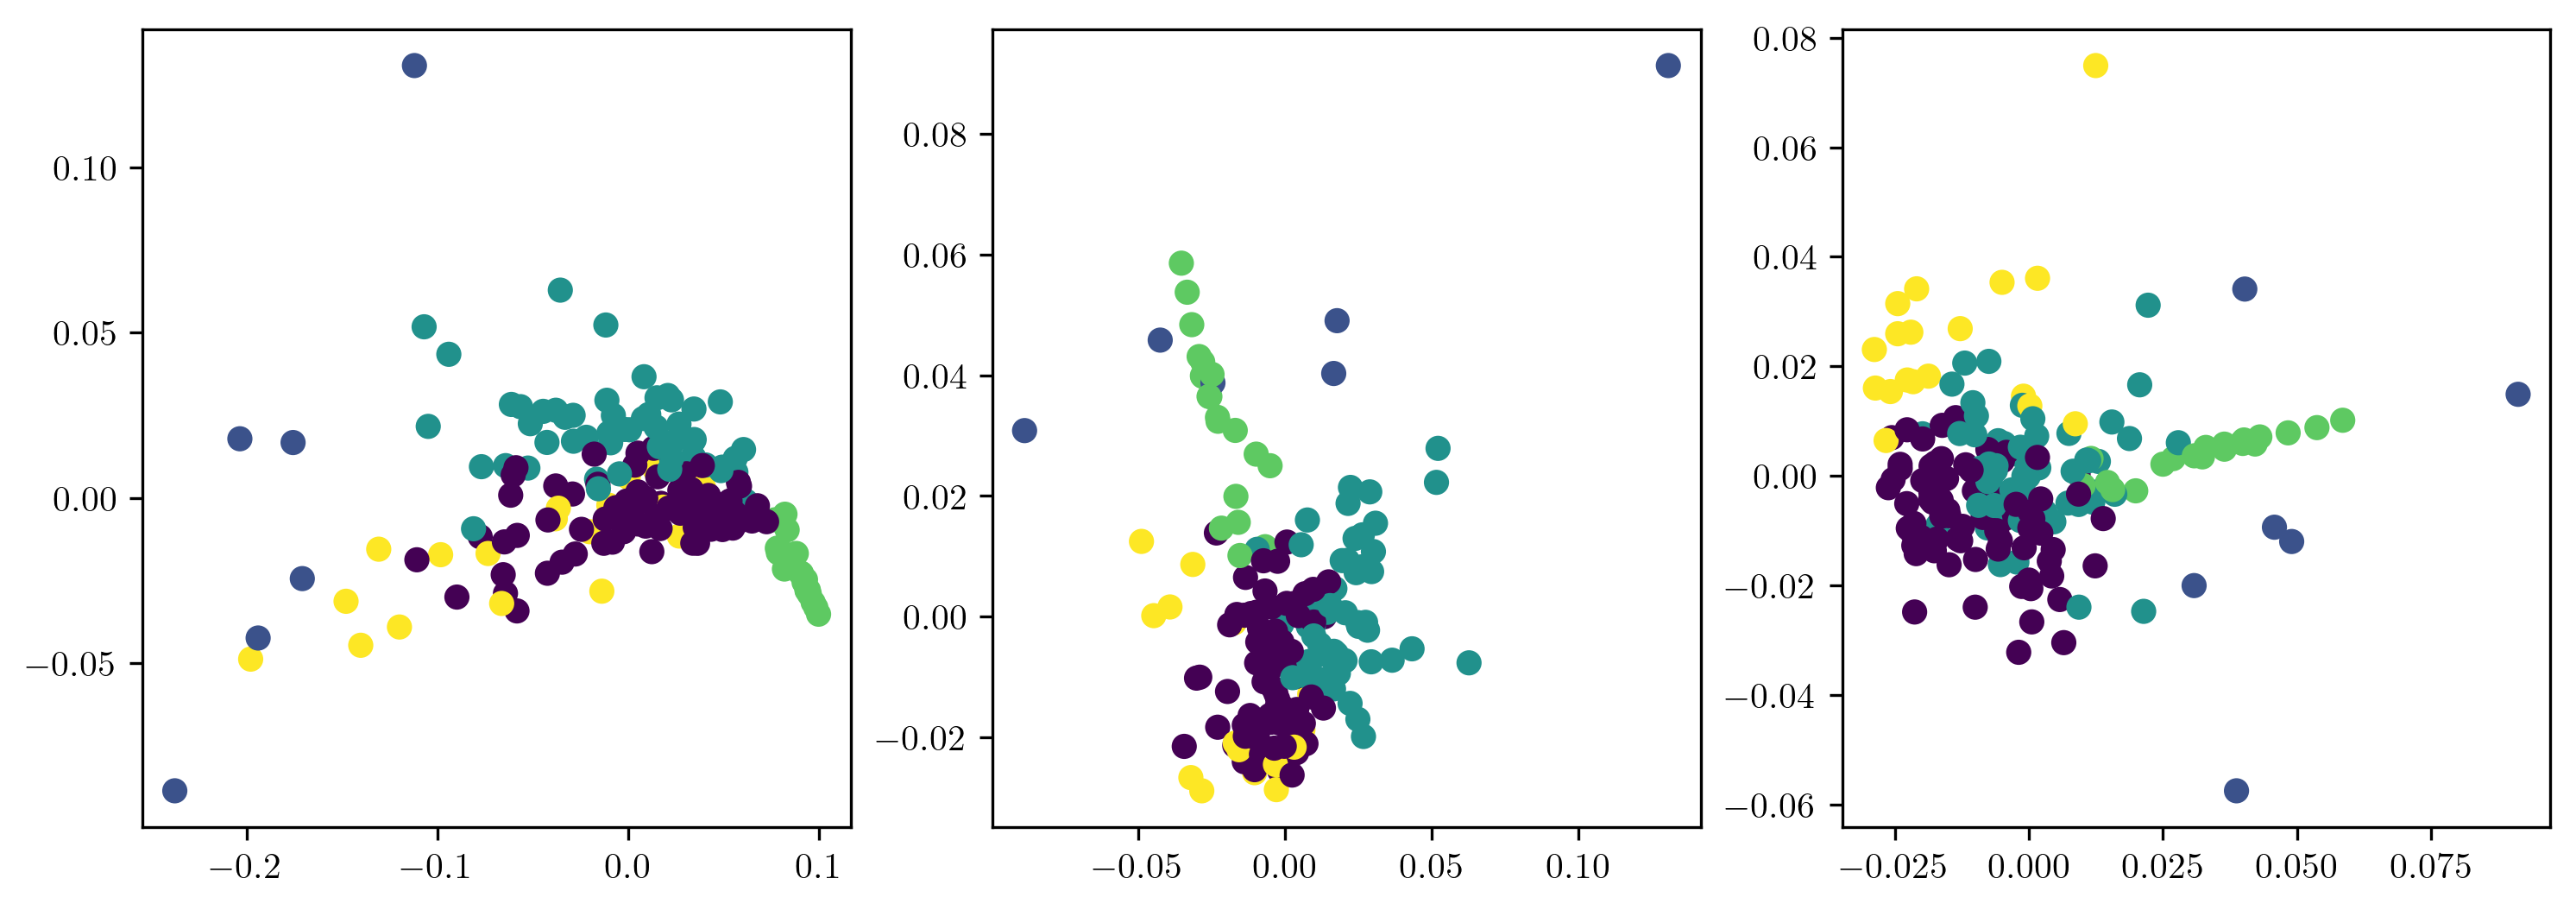

In [4]:
fig, ax = plt.subplots(
    1, 3,
    figsize=(12, 4),
    facecolor='white',
    edgecolor='black',
    dpi=300
)

ax[0].scatter(scores[0], scores[1], c=clustering['pred'])
ax[1].scatter(scores[1], scores[2], c=clustering['pred'])
ax[2].scatter(scores[2], scores[3], c=clustering['pred'])

plt.show()

In [5]:
# Create average player per cluster
mean_clusters = []
mean_scores = np.zeros((5, 20))
for idx in range(5):
    mean_scores[idx, :] = np.mean(scores.query(f"cluster == {idx}").loc[:, 0:19].values, axis=0)
    mean_clusters.append(ufpca.inverse_transform(mean_scores[idx, :][None]))

In [6]:
# Get the max to normalize the density for the visualization
max_val = 0
for data in mean_clusters:
    max_val = max(max_val, data.values.max())

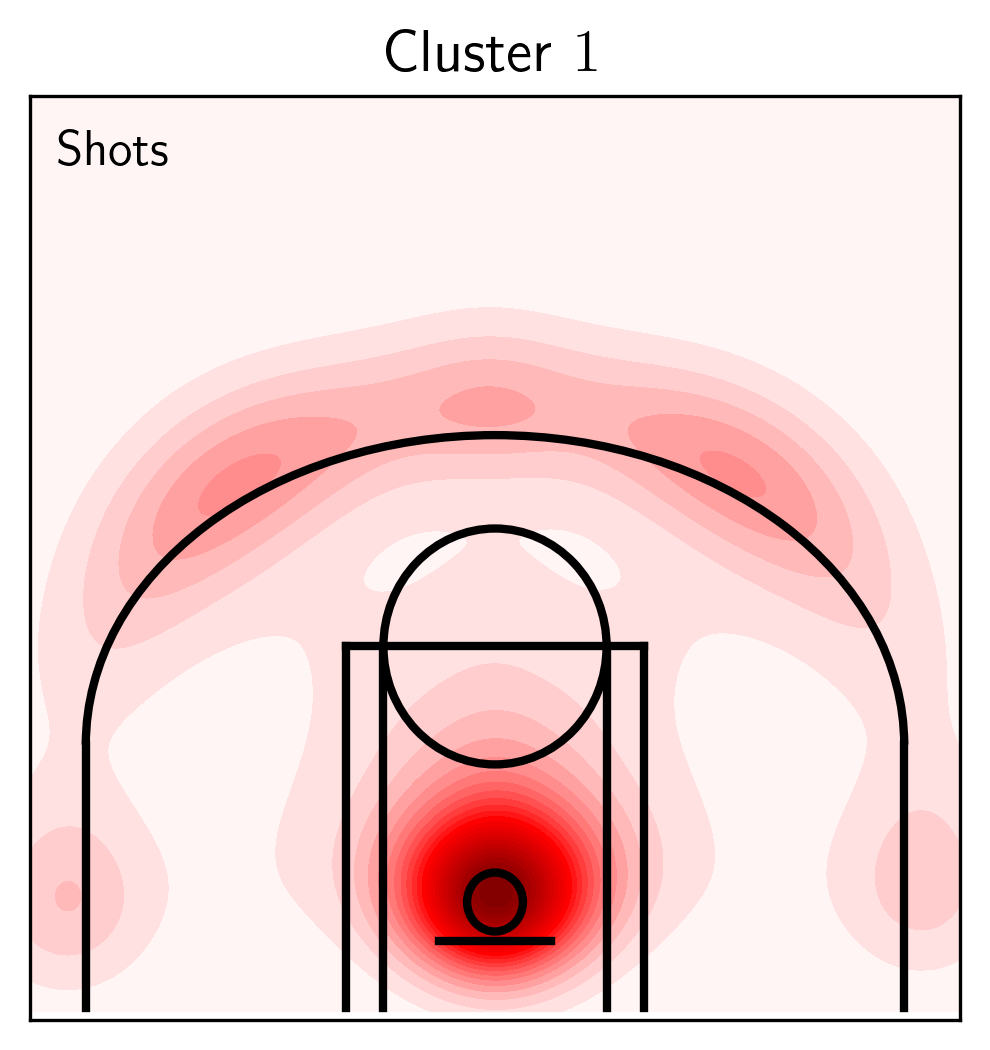

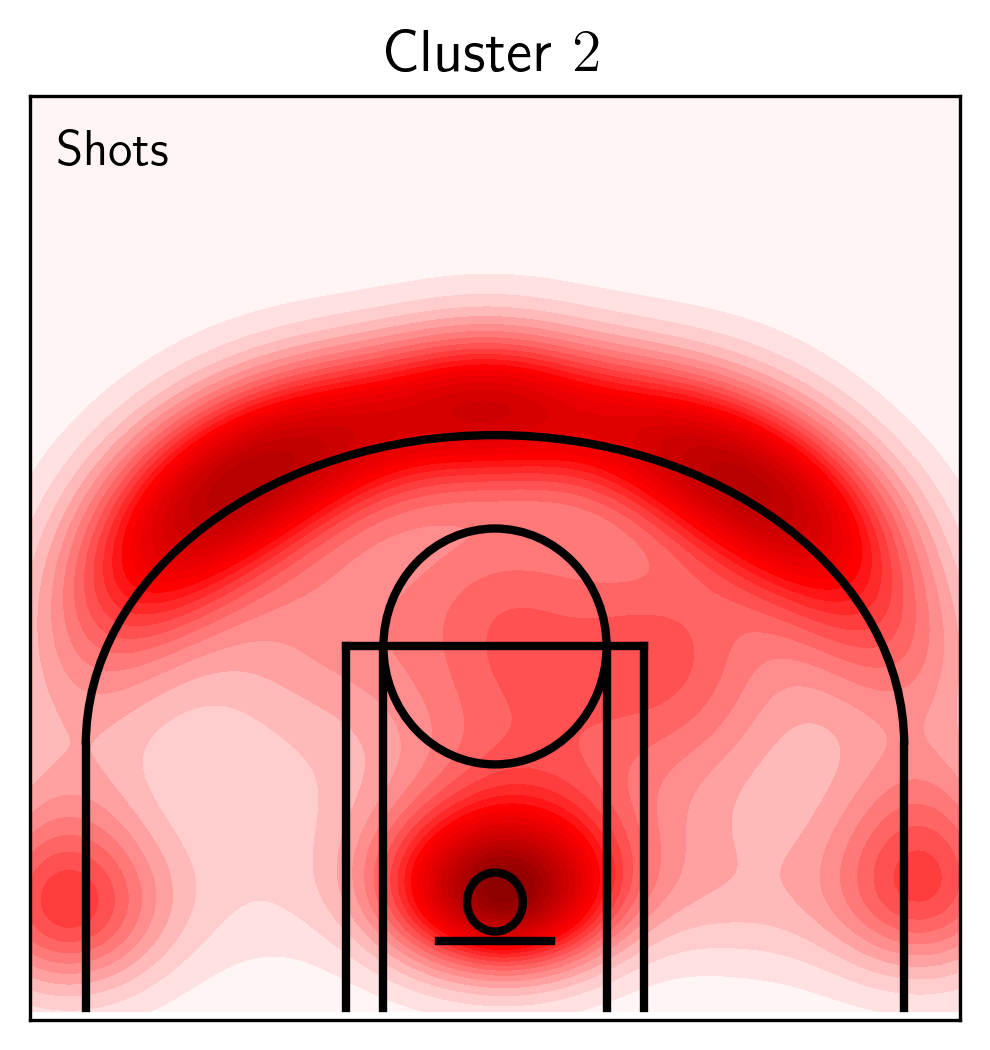

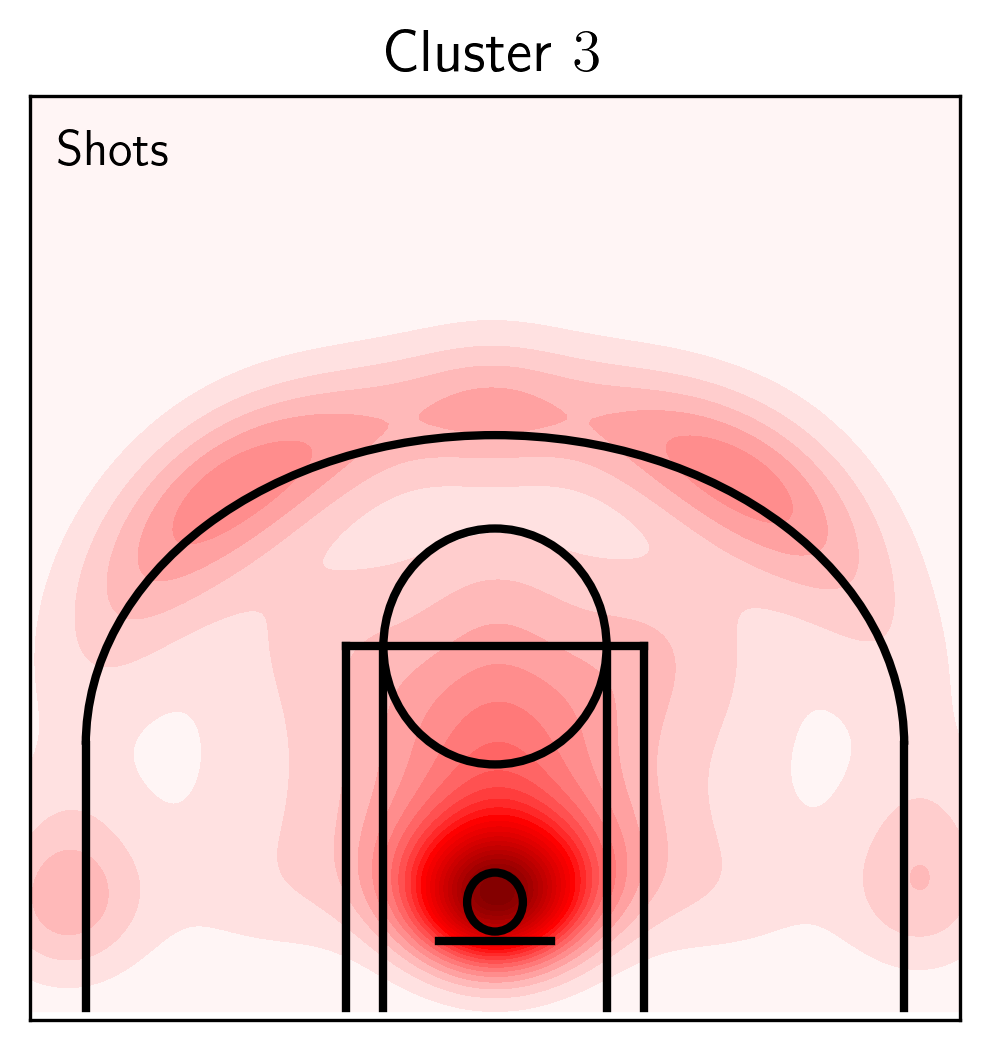

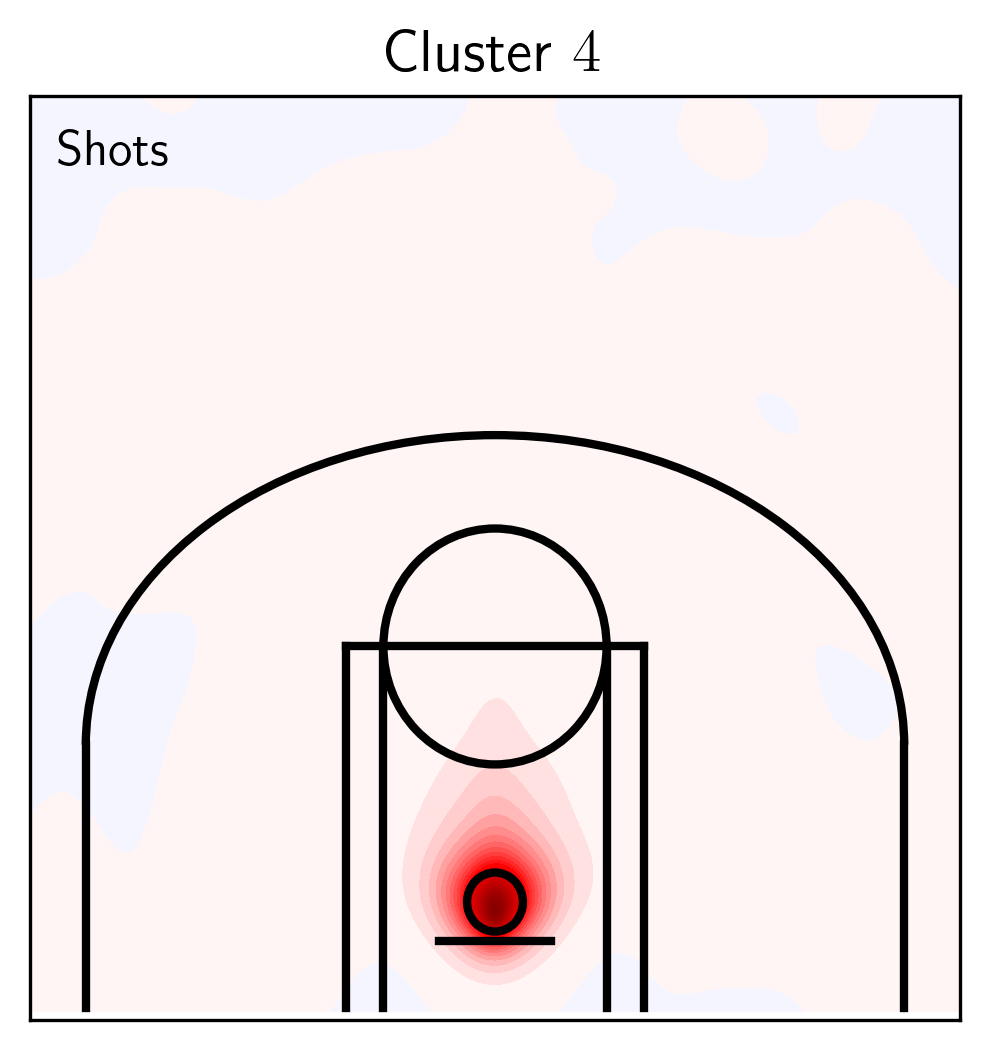

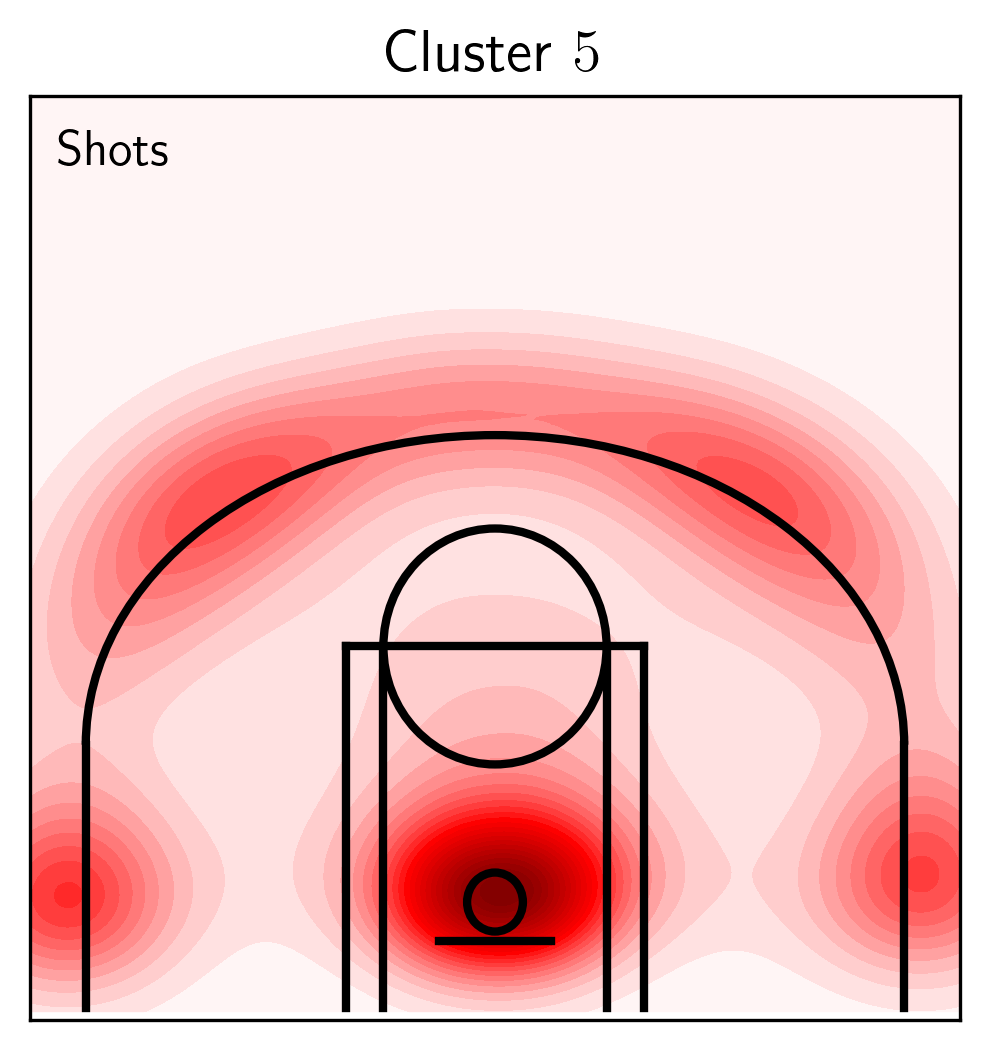

In [7]:
for idx in range(5):
    fig, ax = plt.subplots(
        1, 1,
        figsize=(4, 4),
        facecolor='white',
        edgecolor='black',
        dpi=300
    )

    ax.set_title(f"Cluster ${idx + 1}$", fontsize='x-large')
    ax = ShotCharts.shots_chart_fdata(
        ax, mean_clusters[idx][0], 'Shots', max_val
    )

    # plt.savefig(f'./figures/kmeans_average_cluster_{idx + 1}.eps', transparent=True, format='eps')

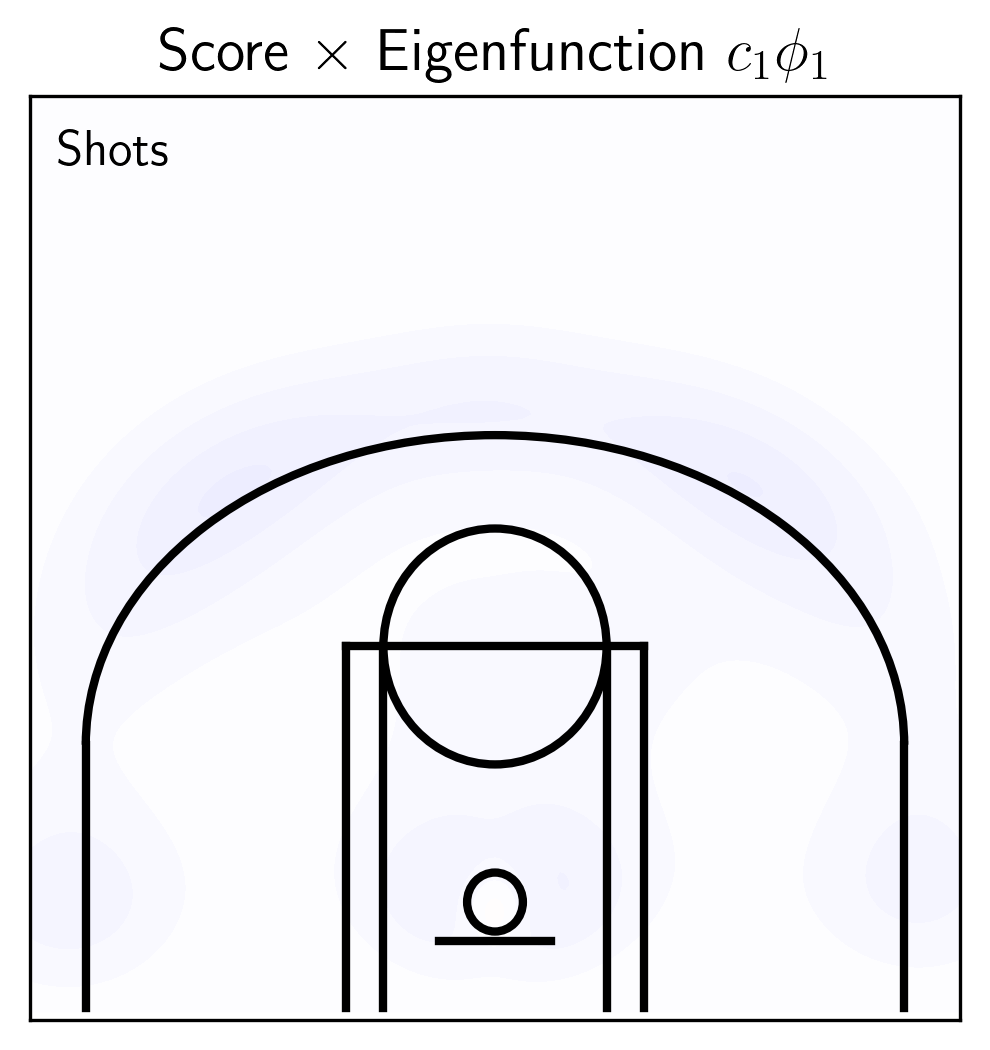

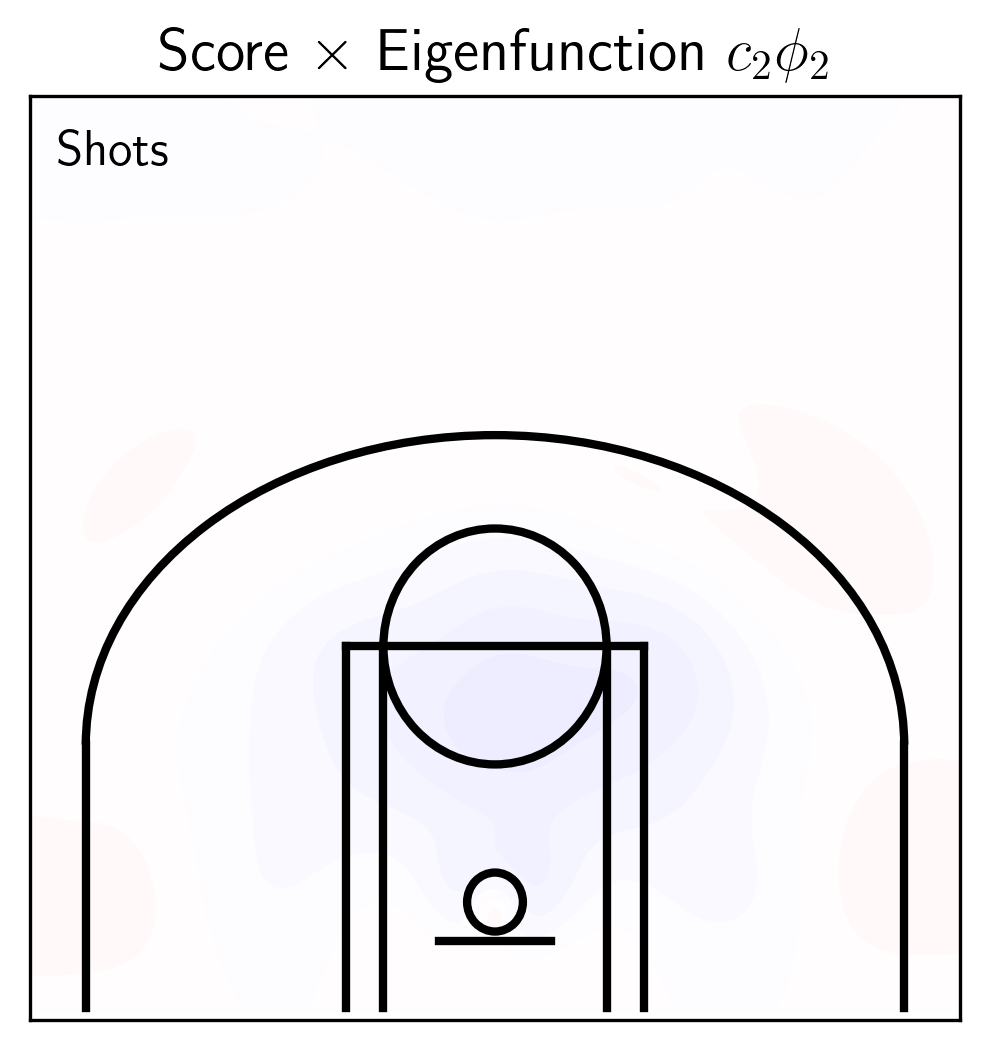

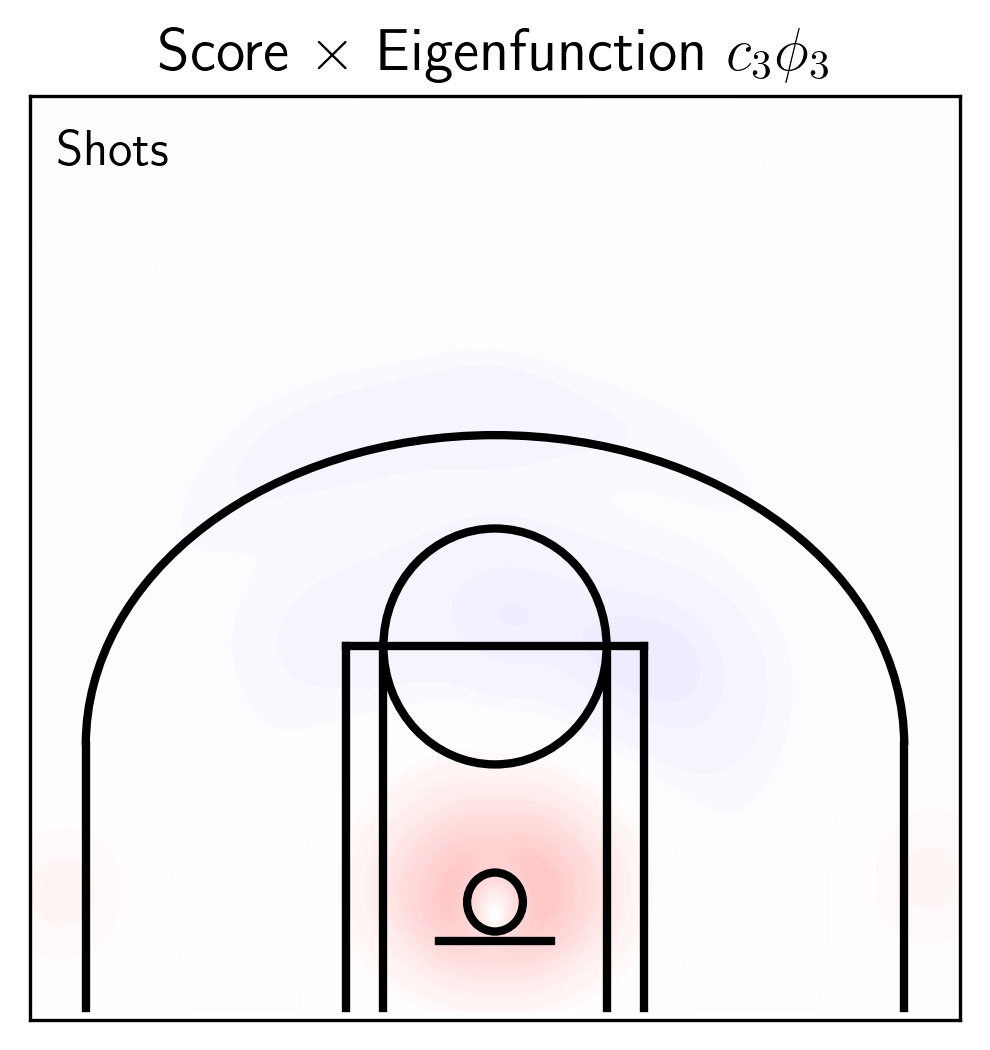

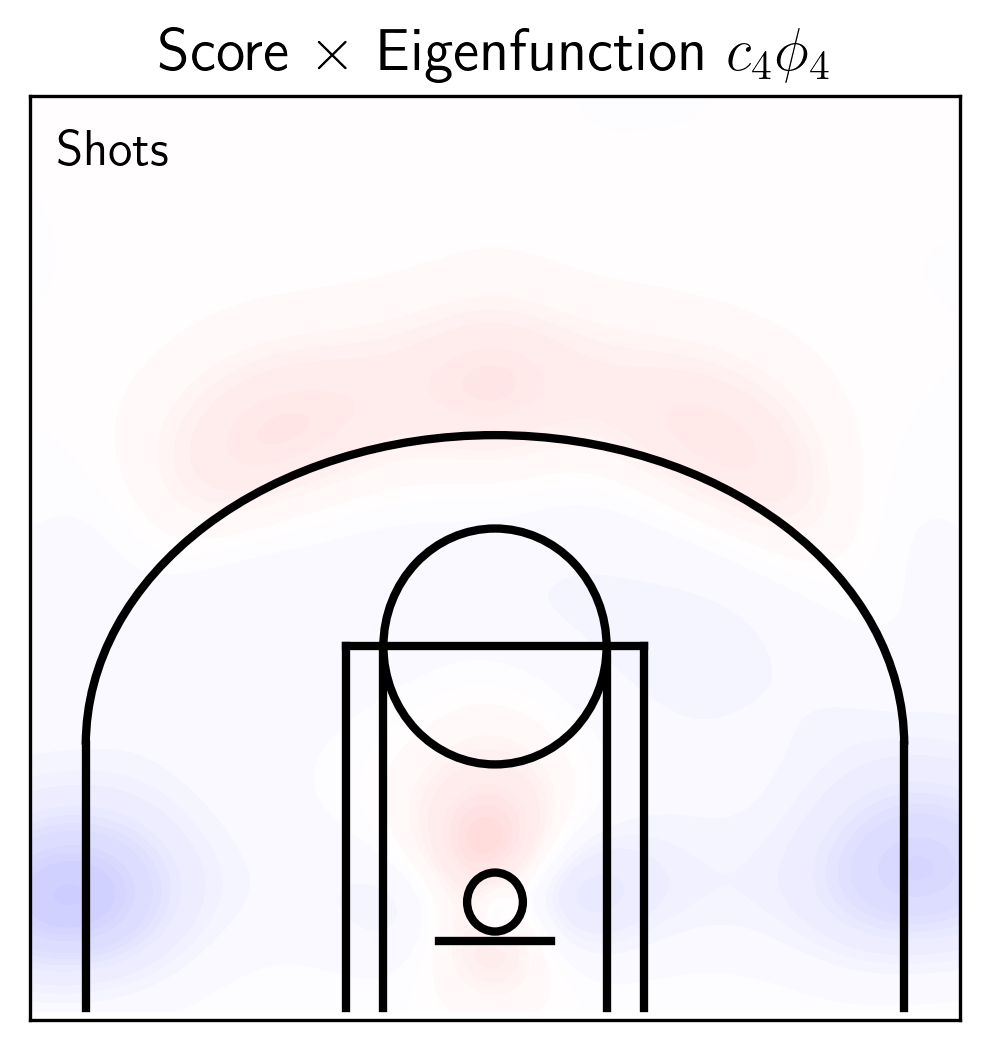

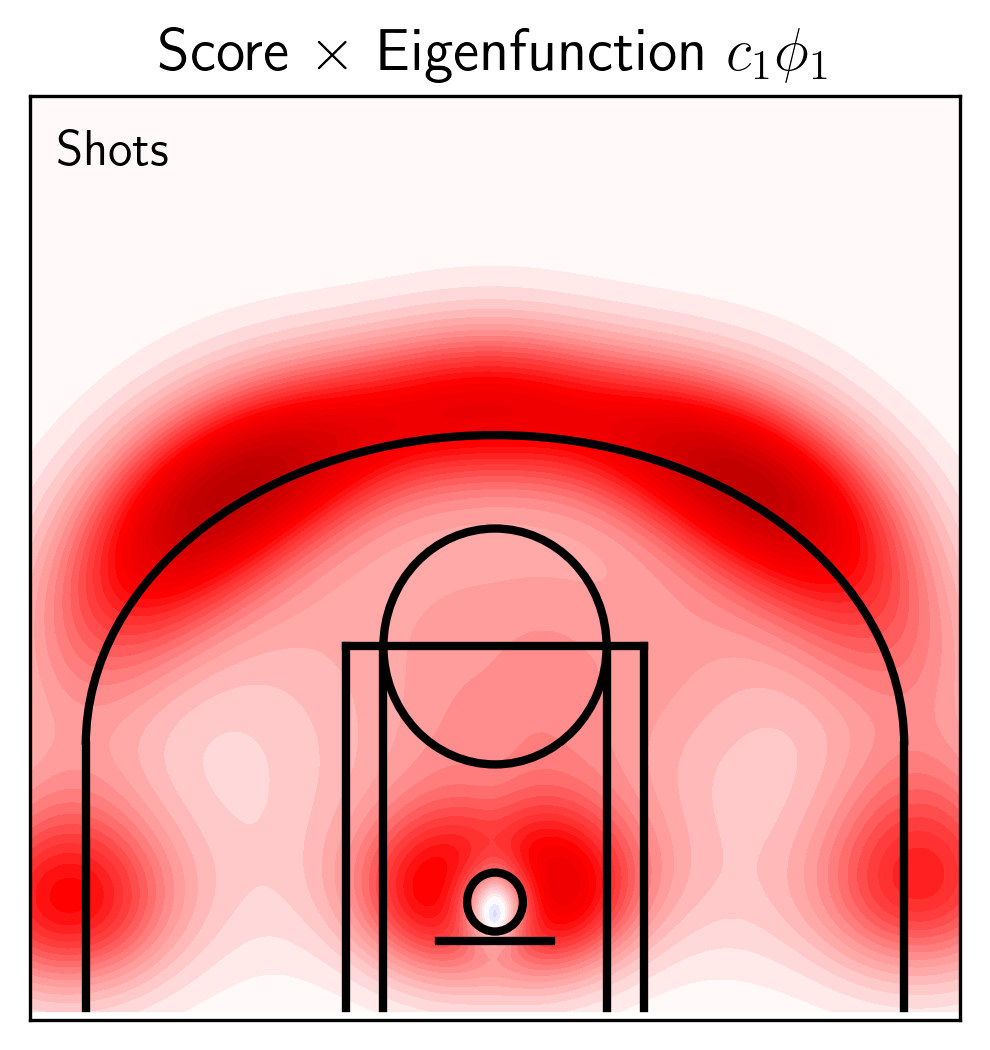

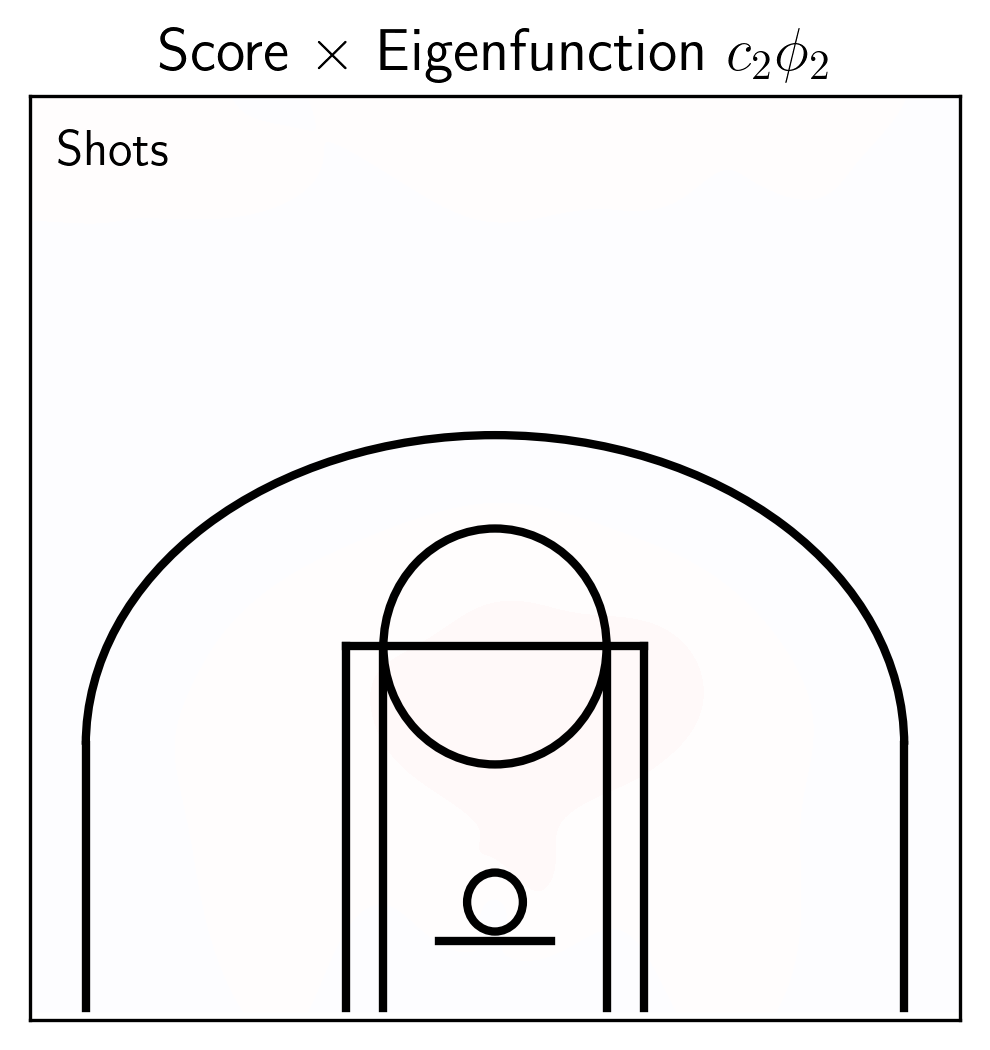

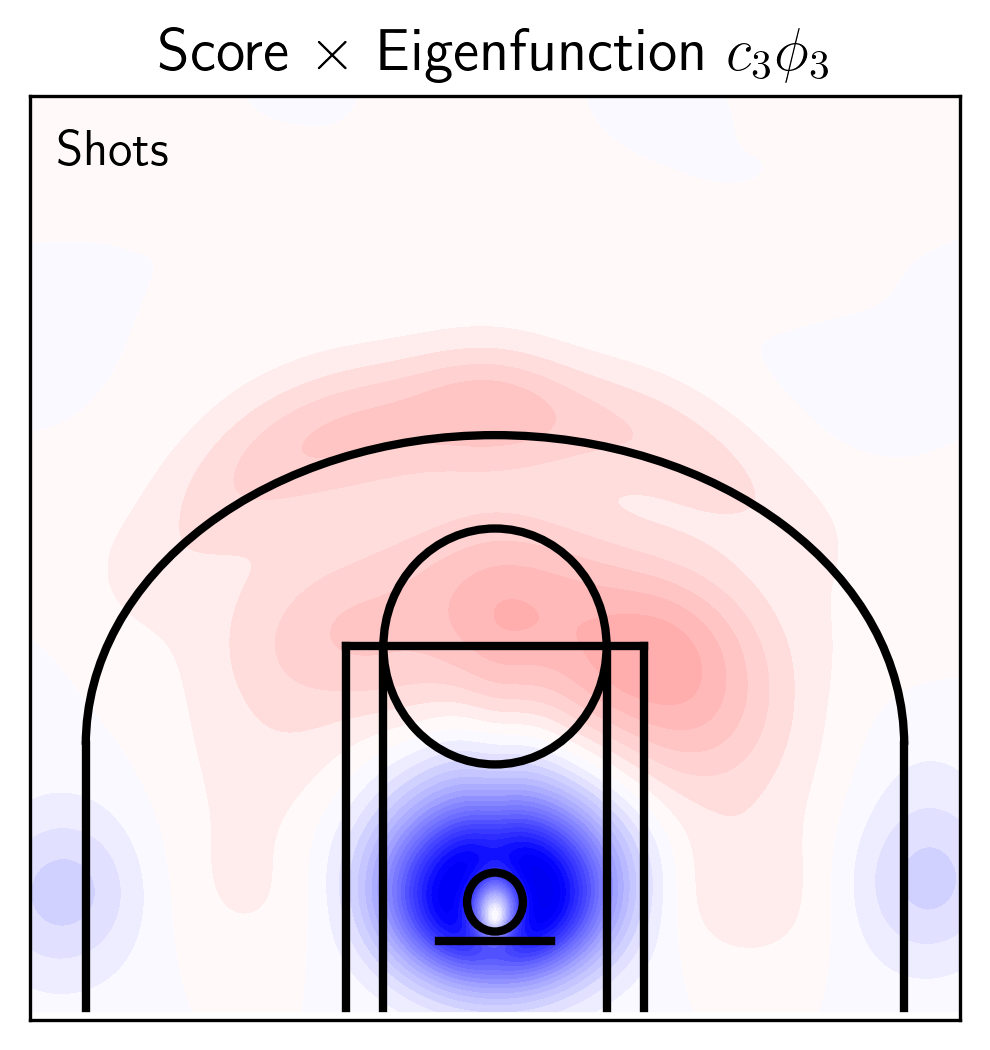

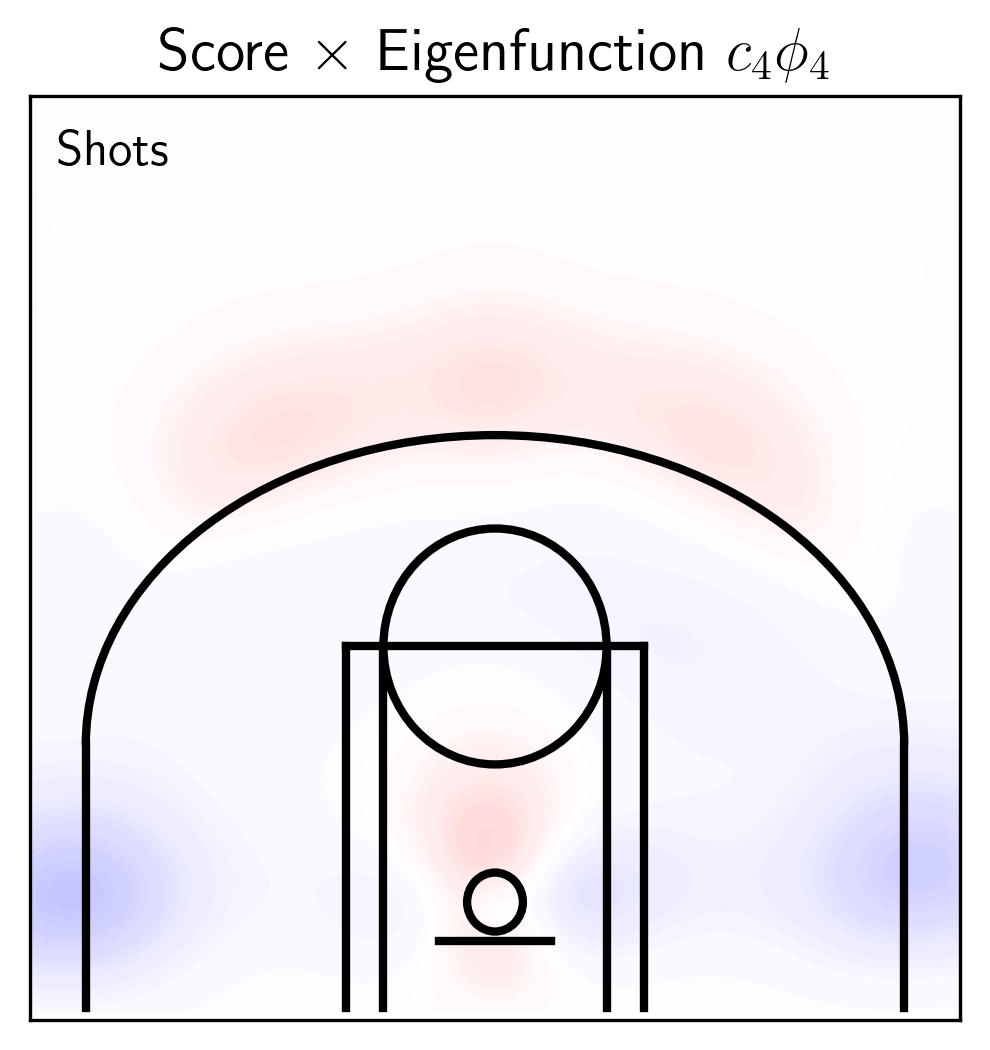

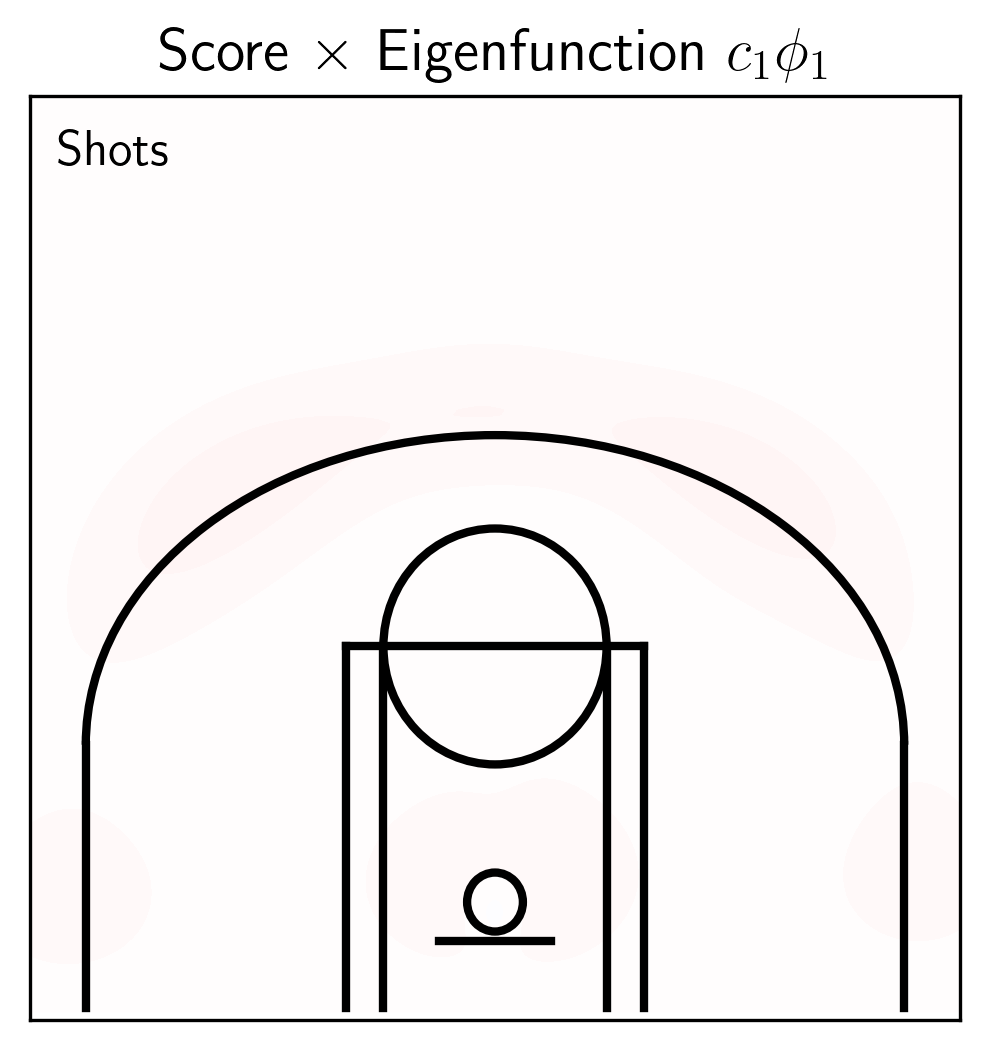

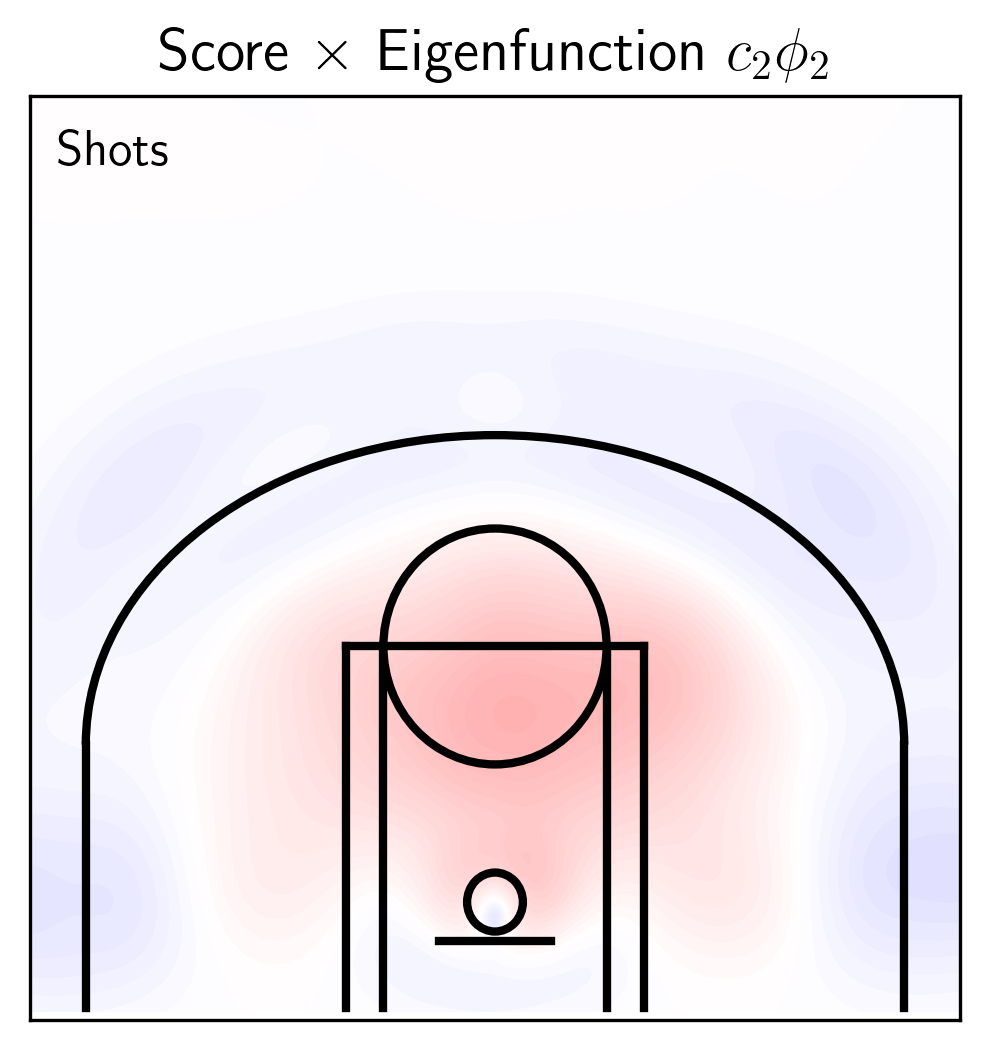

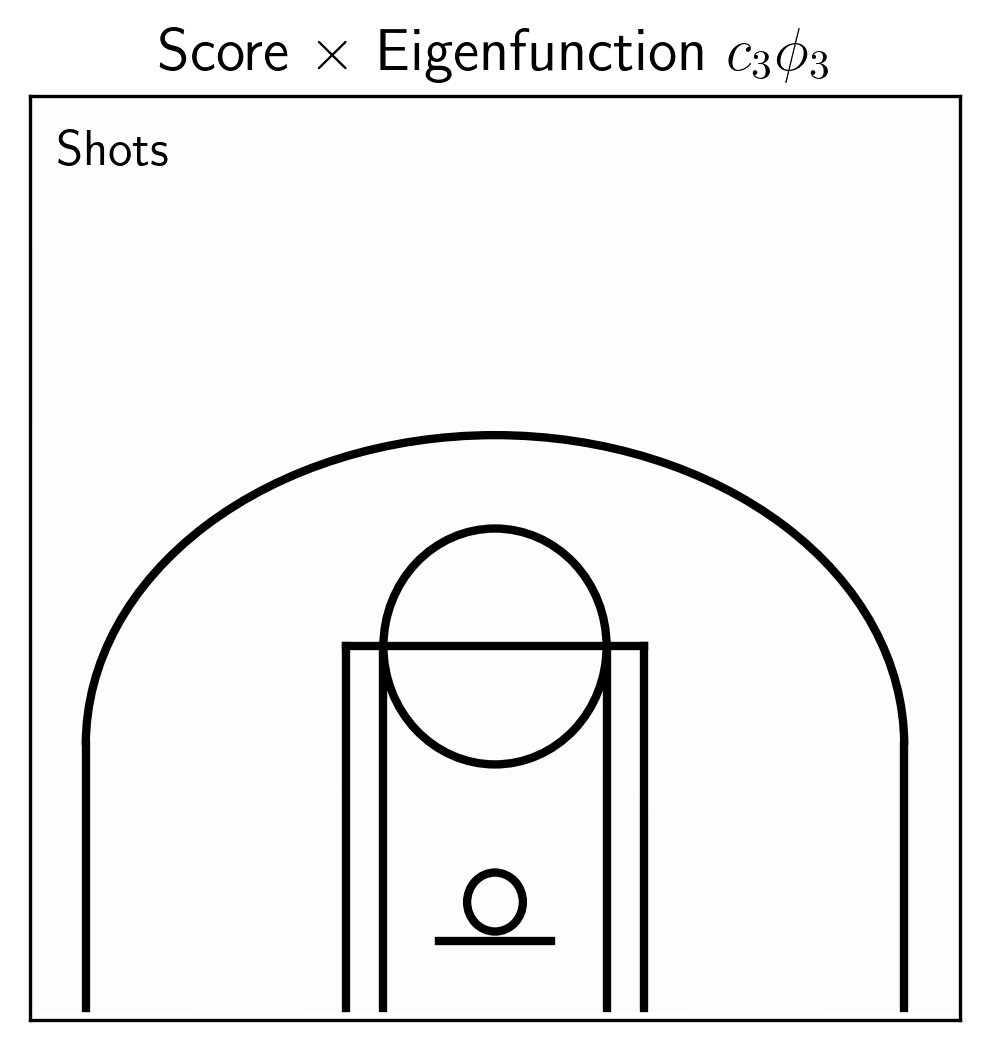

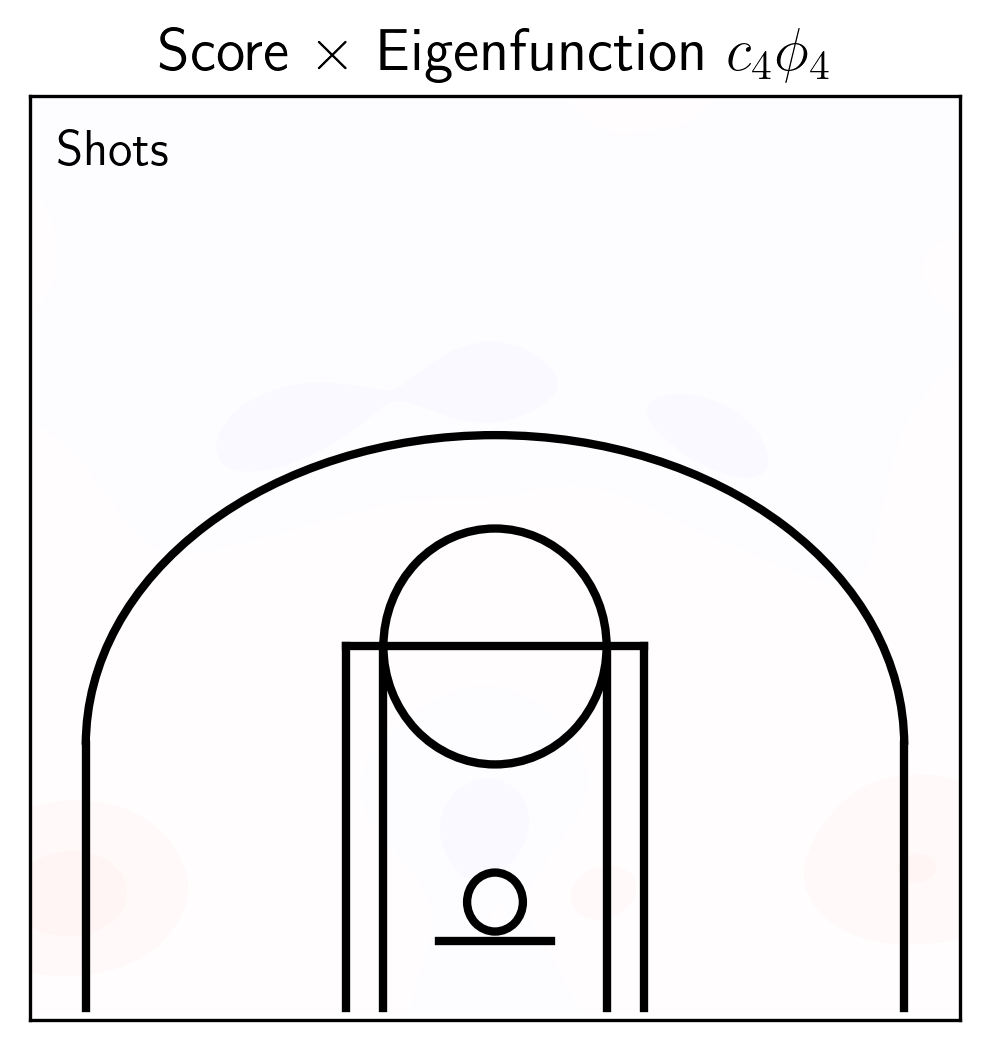

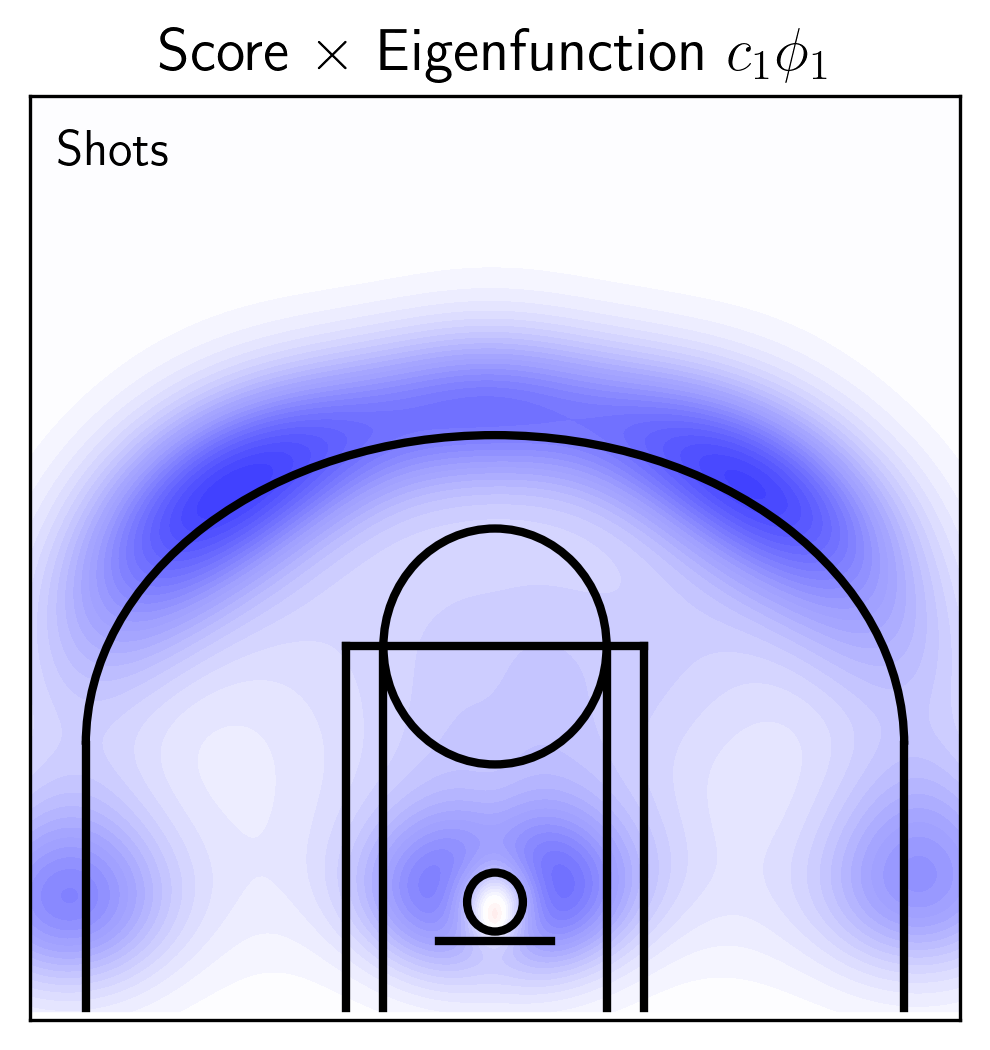

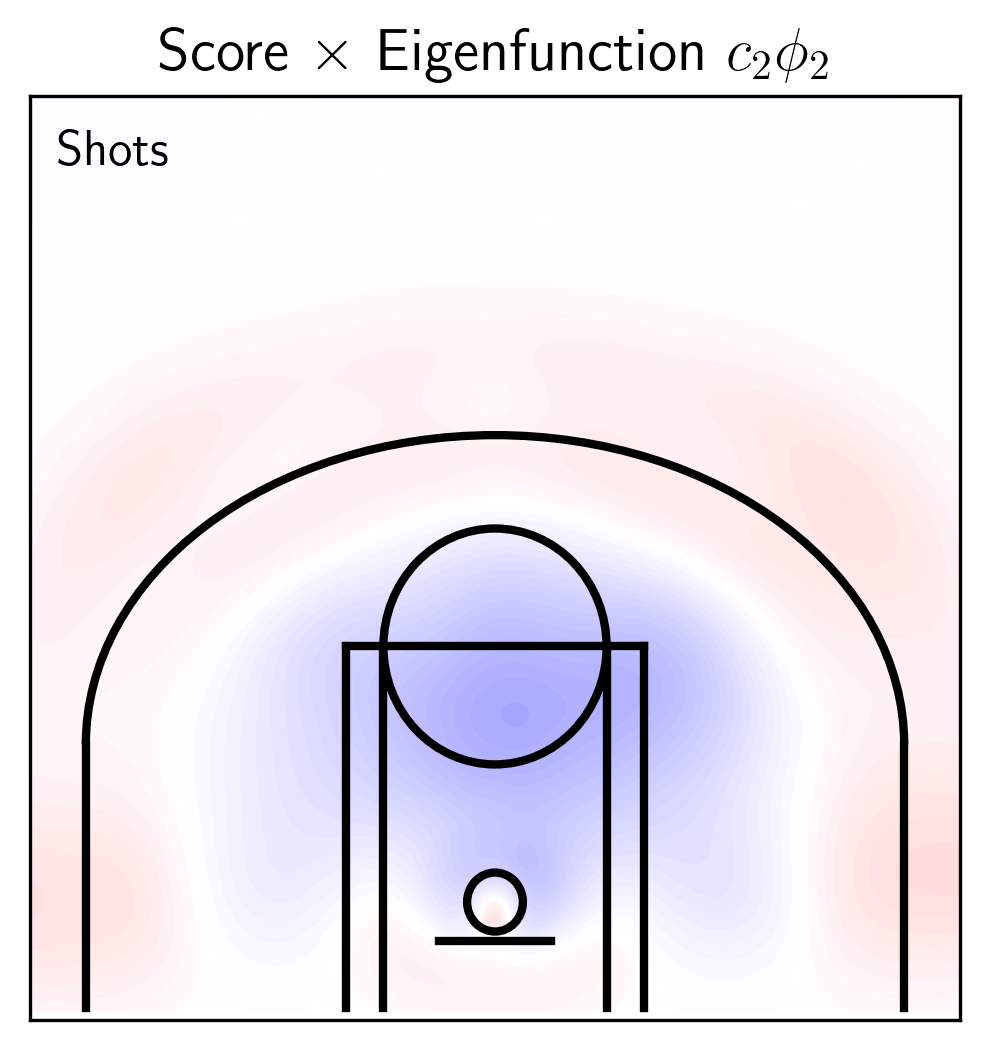

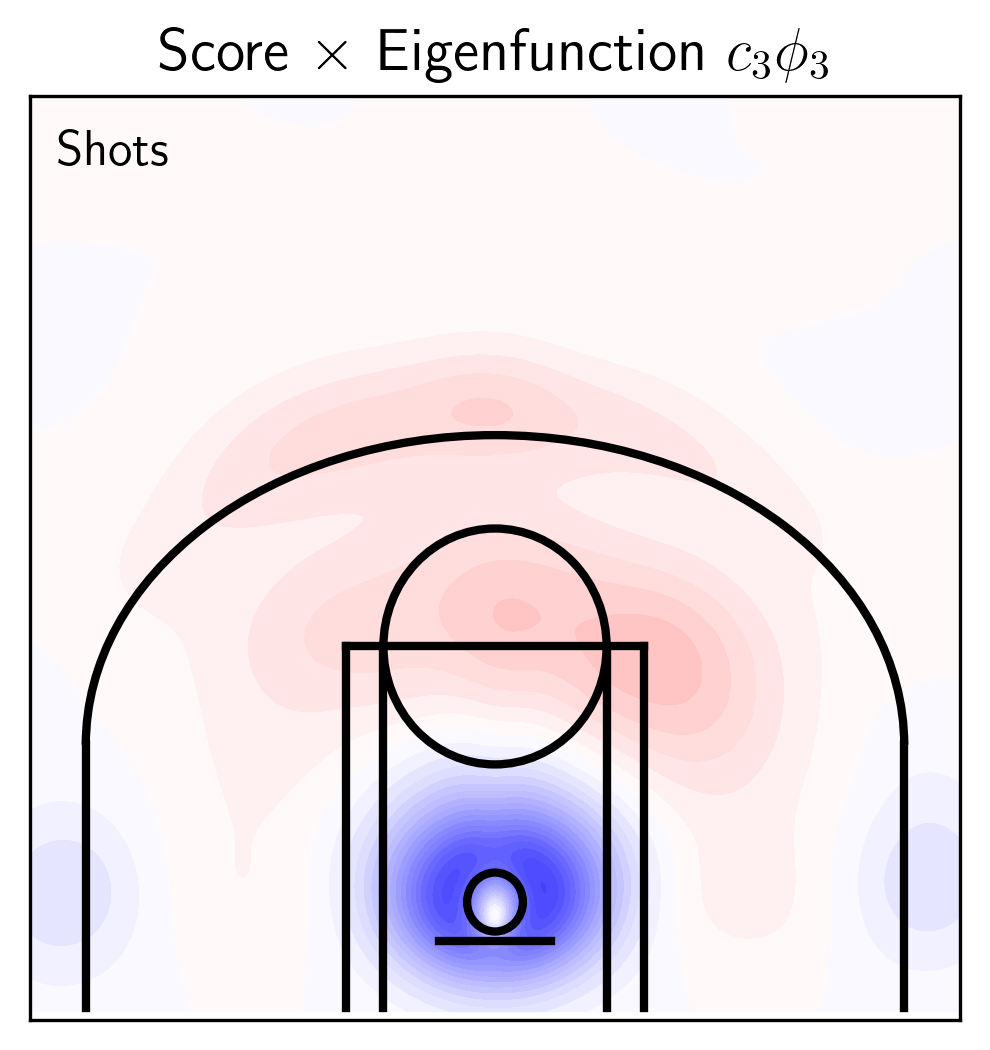

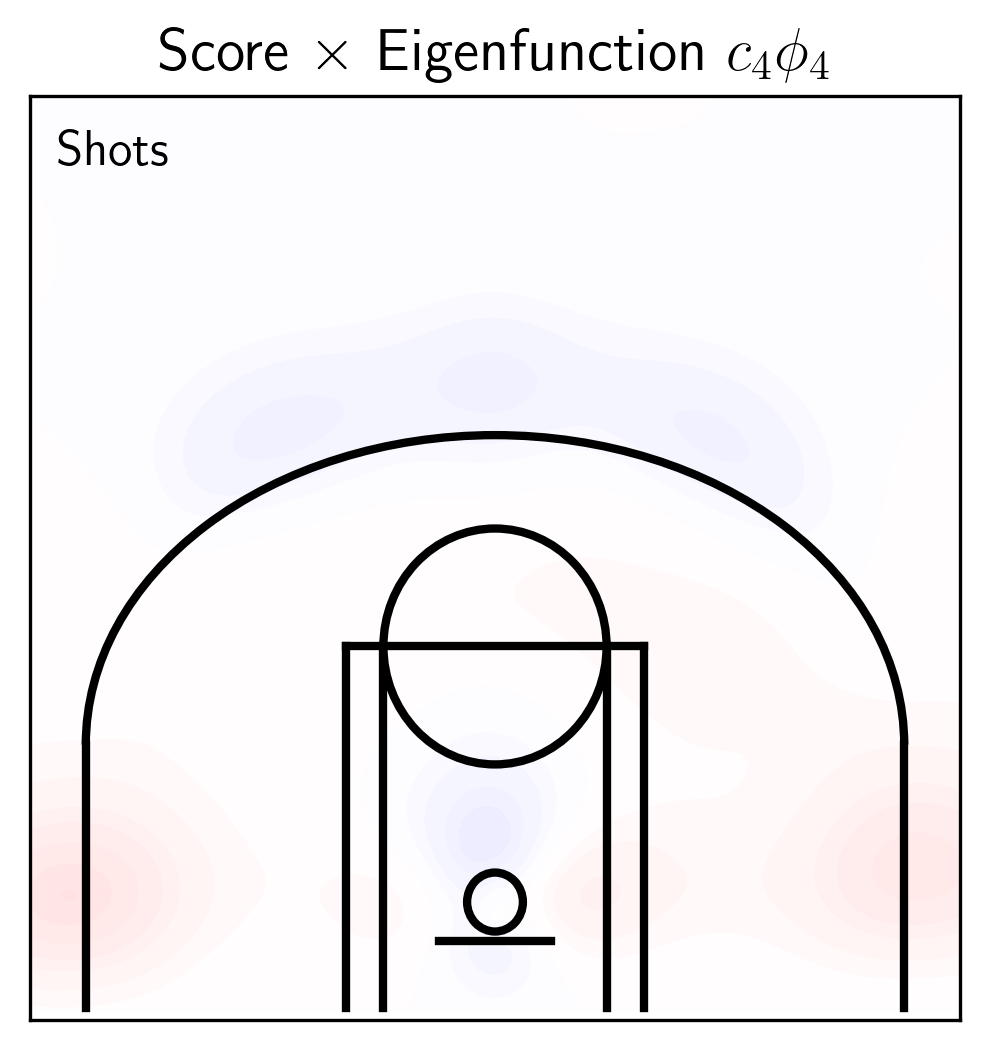

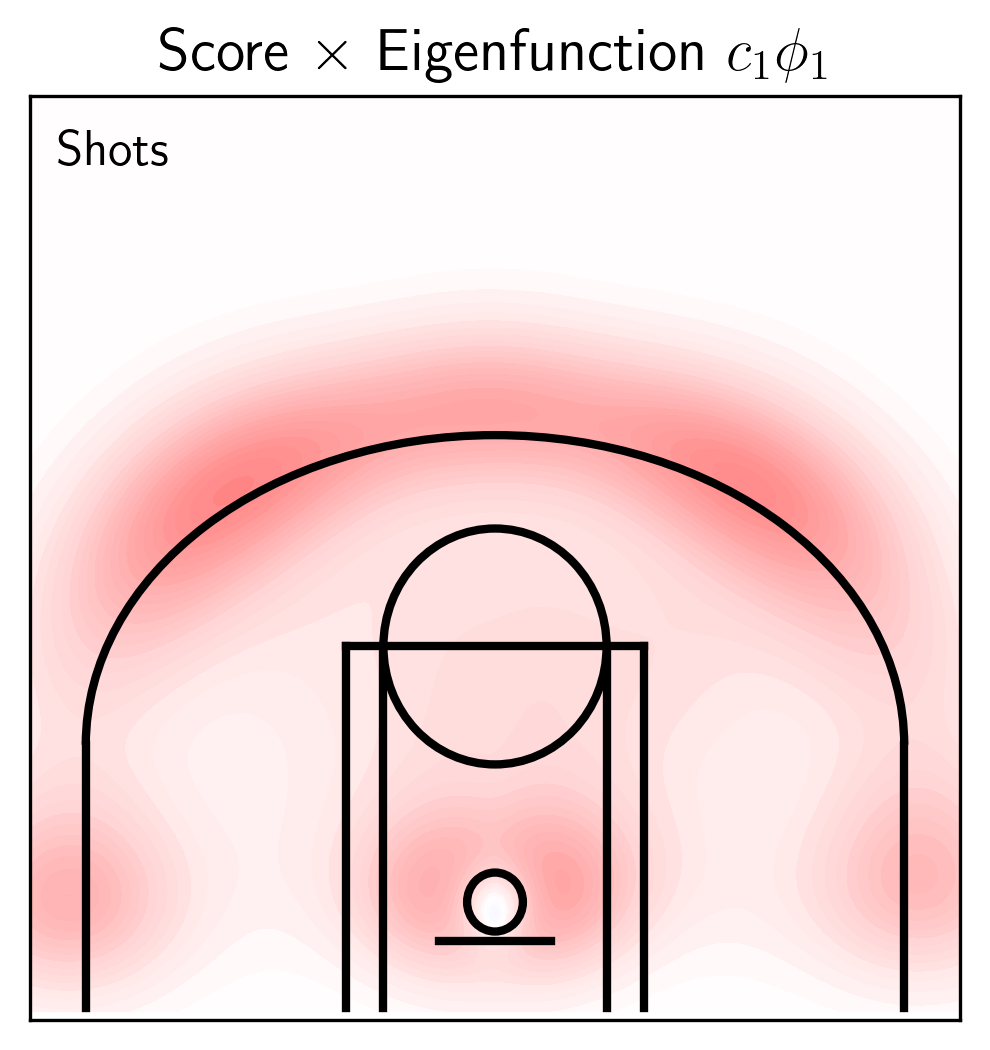

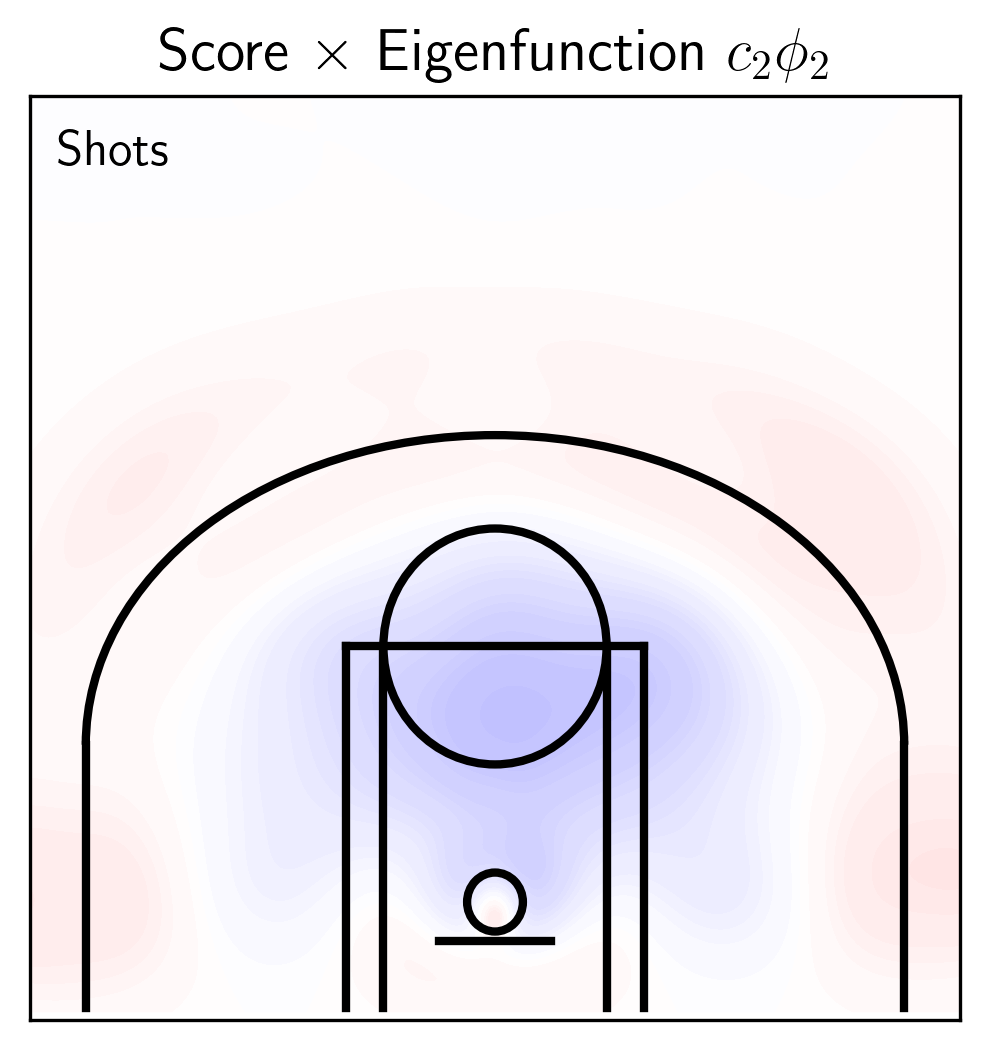

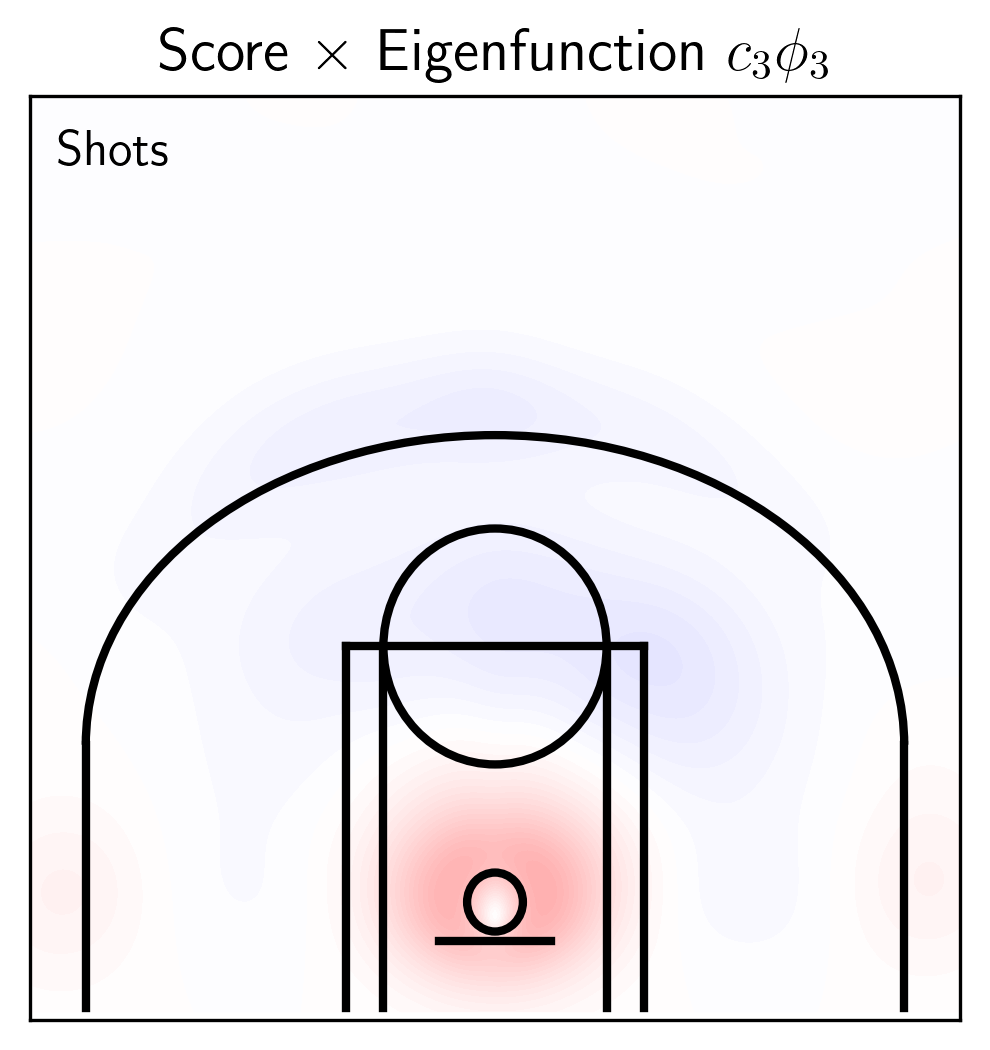

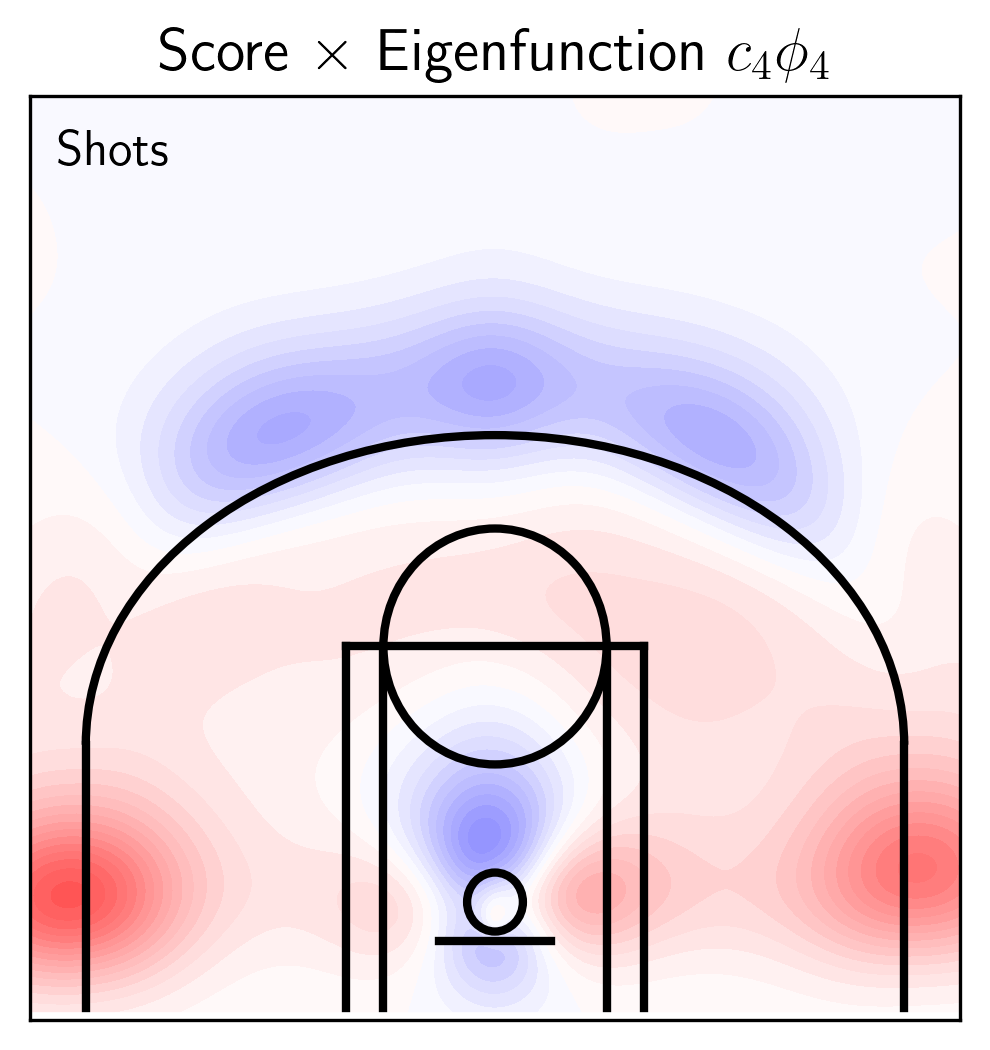

In [8]:
# Decomposition cluster
for c in range(5):
    for idx in range(4):
        fig, ax = plt.subplots(
            1, 1,
            figsize=(4, 4),
            facecolor='white',
            edgecolor='black',
            dpi=300
        )
        maxi = np.max(np.abs(
            np.einsum('i, jk -> ijk', scores[idx].values, ufpca.eigenfunctions[idx].values.squeeze())
        ))

        ax.set_title(f"Score $\\times$ Eigenfunction $c_{{{idx + 1}}}\phi_{{{idx + 1}}}$", fontsize='x-large')
        ax = ShotCharts.shots_decomposition_cluster(
            ax, ufpca, mean_scores[c, idx], idx, 0, 'Shots', maxi
        )
        # plt.savefig(f'./figures/kmeans_cluster_{c + 1}_eigenfunction_{idx + 1}.eps', transparent=True, format='eps')


[Text(0, 0, 'Guard'),
 Text(0, 1, 'Forward-Guard'),
 Text(0, 2, 'Forward'),
 Text(0, 3, 'Forward-Center'),
 Text(0, 4, 'Center')]

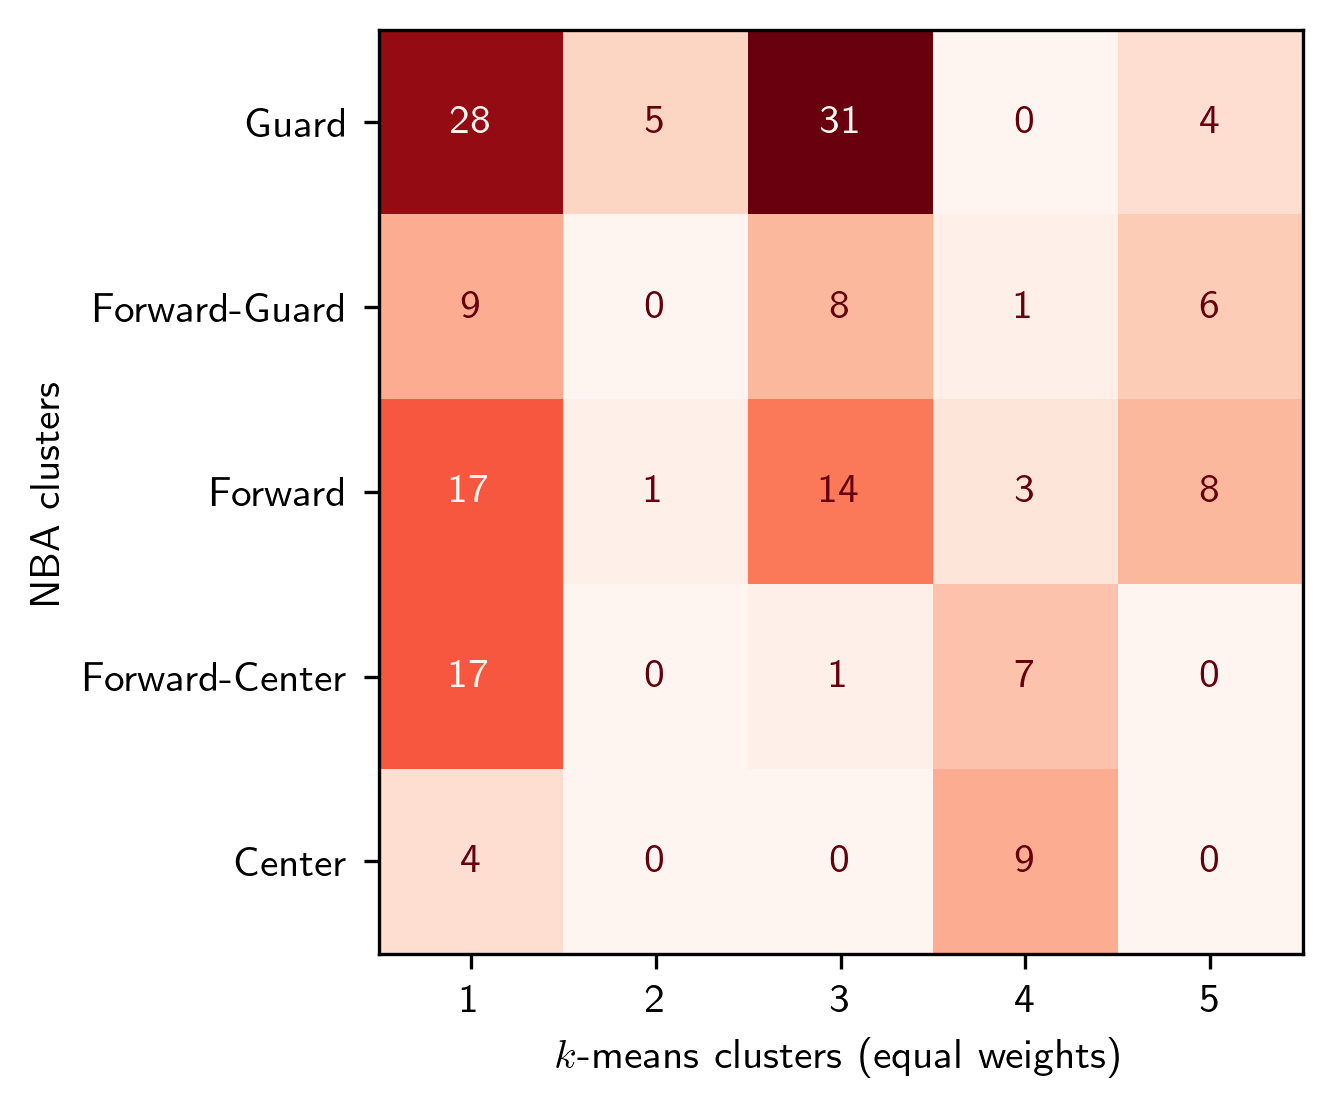

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

scores["POSITION_CAT"] = scores["POSITION_"].map(POSITION_CAT)

fig, ax = plt.subplots(
    1, 1,
    figsize=(6, 4),
    facecolor='white',
    edgecolor='black',
    dpi=300
)

confusion_mat = ConfusionMatrixDisplay.from_predictions(
    scores['POSITION_CAT'],
    scores['cluster'] + 1,
    cmap='Reds',
    colorbar=False,
    ax=ax
)
confusion_mat.ax_.set_xlabel("$k$-means clusters (equal weights)")
confusion_mat.ax_.set_ylabel("NBA clusters")
confusion_mat.ax_.set_yticklabels(['Guard', 'Forward-Guard', 'Forward', 'Forward-Center', 'Center'])
# plt.savefig(f'./figures/confusion_mat_kmeans_no_weights.eps', transparent=True, format='eps')

In [10]:
# Adjusted Rand Index
from sklearn.metrics import adjusted_rand_score

adjusted_rand_score(scores['POSITION_CAT'], scores['cluster'] + 1)

0.07230037622822451

In [11]:
# Silhouette Score
from sklearn.metrics import silhouette_score

silhouette_score(distance_scores, scores['cluster'] + 1, metric='precomputed')

0.25625240166947544